#  1-**ANALYSE DU SIGNAL**
------------------------------------------------------------------------------------------------

## A-*TRACONS ET VISUALISONS LE SIGNAL PORTE P(t)*

\[
p(t)=
\begin{cases}
A & \text{si } |t|\le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
\]

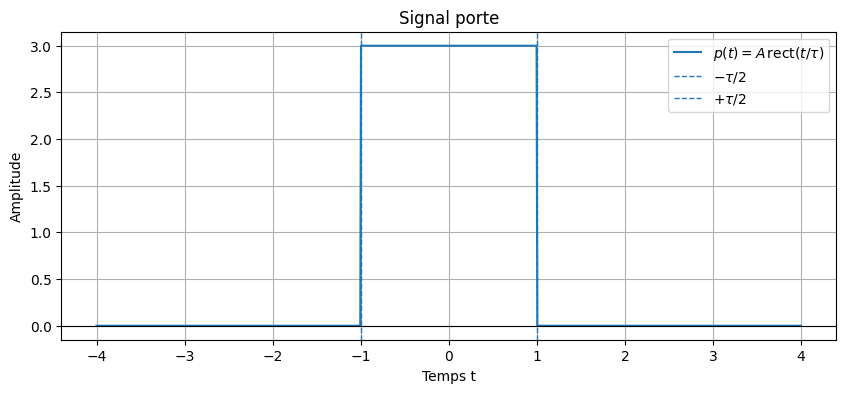

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du signal
A = 3          # amplitude
tau = 2        # largeur de l'impulsion

# Axe du temps
t = np.linspace(-4, 4, 1000)

# Définition du signal porte
p = np.where(np.abs(t) <= tau/2, A, 0)

# Tracé
plt.figure(figsize=(10, 4))
plt.plot(t, p, label=r"$p(t)=A\,\mathrm{rect}(t/\tau)$")
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(-tau/2, linestyle='--', linewidth=1, label=r"$-\tau/2$")
plt.axvline(tau/2, linestyle='--', linewidth=1, label=r"$+\tau/2$")

plt.title("Signal porte")
plt.xlabel("Temps t")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.show()

## B-*CALCULON CA TRANSFORMER DE FOURIER* 

# Transformée de Fourier du signal porte

On considère le signal porte :

$$
p(t)=
\begin{cases}
A & \text{si } |t|\le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

---

## 1) Rappel de la définition de la transformée de Fourier

On adopte la convention :

$$
P(f)=\int_{-\infty}^{+\infty} p(t)\,e^{-j2\pi f t}\,dt
$$

où :

- $p(t)$ est le signal dans le domaine temporel,
- $P(f)$ est sa transformée de Fourier dans le domaine fréquentiel,
- $f$ est la fréquence en Hz,
- $j^2=-1$.

---

## 2) Utilisation de la définition du signal porte

Comme le signal vaut :

- $A$ pour $t \in \left[-\dfrac{\tau}{2},\dfrac{\tau}{2}\right]$,
- $0$ ailleurs,

alors l'intégrale sur tout $\mathbb{R}$ se réduit à l'intervalle où le signal n'est pas nul :

$$
P(f)=\int_{-\infty}^{+\infty} p(t)e^{-j2\pi ft}dt
=
\int_{-\tau/2}^{+\tau/2} A\,e^{-j2\pi ft}dt
$$

Comme $A$ est une constante, on peut la sortir de l'intégrale :

$$
P(f)=A\int_{-\tau/2}^{+\tau/2} e^{-j2\pi ft}dt
$$

---

## 3) Calcul de l'intégrale

On doit calculer :

$$
\int e^{-j2\pi ft}dt
$$

La primitive de $e^{-j2\pi ft}$ par rapport à $t$ est :

$$
\frac{e^{-j2\pi ft}}{-j2\pi f}
$$

Donc :

$$
P(f)=A\left[\frac{e^{-j2\pi ft}}{-j2\pi f}\right]_{-\tau/2}^{+\tau/2}
$$

On applique maintenant les bornes :

$$
P(f)=A\left(
\frac{e^{-j2\pi f(\tau/2)}-e^{-j2\pi f(-\tau/2)}}{-j2\pi f}
\right)
$$

Simplifions les exposants :

$$
e^{-j2\pi f(\tau/2)}=e^{-j\pi f\tau}
\qquad\text{et}\qquad
e^{-j2\pi f(-\tau/2)}=e^{j\pi f\tau}
$$

Donc :

$$
P(f)=A\left(
\frac{e^{-j\pi f\tau}-e^{j\pi f\tau}}{-j2\pi f}
\right)
$$

---

## 4) Utilisation de l'identité d'Euler

On utilise l'identité classique :

$$
e^{j\theta}-e^{-j\theta}=2j\sin(\theta)
$$

Donc :

$$
e^{-j\pi f\tau}-e^{j\pi f\tau}=-2j\sin(\pi f\tau)
$$

En remplaçant dans l'expression précédente :

$$
P(f)=A\frac{-2j\sin(\pi f\tau)}{-j2\pi f}
$$

Les termes $-2j$ au numérateur et $-j2$ au dénominateur se simplifient, il reste :

$$
P(f)=A\frac{\sin(\pi f\tau)}{\pi f}
$$

---

## 5) Mise sous forme plus classique

On peut faire apparaître $\tau$ en multipliant et divisant par $\tau$ :

$$
P(f)=A\tau\frac{\sin(\pi f\tau)}{\pi f\tau}
$$

On reconnaît alors la fonction sinus cardinal :

$$
\mathrm{sinc}(x)=\frac{\sin(\pi x)}{\pi x}
$$

Donc :

$$
P(f)=A\tau\,\mathrm{sinc}(f\tau)
$$

---

## 6) Résultat final

$$
\boxed{P(f)=A\tau\,\mathrm{sinc}(f\tau)}
$$

avec :

$$
\boxed{\mathrm{sinc}(f\tau)=\frac{\sin(\pi f\tau)}{\pi f\tau}}
$$

Donc on peut aussi écrire :

$$
\boxed{P(f)=A\frac{\sin(\pi f\tau)}{\pi f}}
$$

Les deux formes sont équivalentes.

---

## 7) Vérification en $f=0$

L'expression :

$$
P(f)=A\tau\frac{\sin(\pi f\tau)}{\pi f\tau}
$$

donne une forme $\dfrac{0}{0}$ pour $f=0$, donc on calcule la limite :

$$
\lim_{f\to 0}\frac{\sin(\pi f\tau)}{\pi f\tau}=1
$$

Ainsi :

$$
P(0)=A\tau
$$

C'est cohérent, car :

$$
P(0)=\int_{-\infty}^{+\infty}p(t)\,dt
$$

or l'aire du signal porte vaut :

$$
\text{aire}=A\times \tau
$$

donc :

$$
P(0)=A\tau
$$

---

## 8) Interprétation physique

Le signal porte dans le temps donne une fonction de type **sinc** dans le domaine fréquentiel.

Cela signifie :

- plus le signal est **large dans le temps** ($\tau$ grand), plus son spectre est **resserré** ;
- plus le signal est **court dans le temps**, plus son spectre est **étalé**.

C'est une idée très importante en traitement du signal et en physique des ondes :

$$
\boxed{\text{signal court dans le temps} \;\Longrightarrow\; \text{spectre large en fréquence}}
$$

---

## 9) Remarque sur la symétrie

Le signal $p(t)$ est :

- réel,
- pair.

Donc sa transformée de Fourier $P(f)$ est également :

- réelle,
- paire.

C'est bien le cas de :

$$
P(f)=A\tau\,\mathrm{sinc}(f\tau)
$$

car la fonction $\mathrm{sinc}$ est paire.

---

## 10) Résumé final à retenir

Pour le signal porte :

$$
p(t)=
\begin{cases}
A & \text{si } |t|\le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

sa transformée de Fourier, avec la convention

$$
P(f)=\int_{-\infty}^{+\infty} p(t)e^{-j2\pi ft}dt
$$

est :

$$
\boxed{P(f)=A\tau\,\mathrm{sinc}(f\tau)}
$$

ou encore :

$$
\boxed{P(f)=A\frac{\sin(\pi f\tau)}{\pi f}}
$$


## C-*TARCONS LA TRANSFORMER DE FOURIER DU SIGNAL PORTE QUI EST UN SINUS CARDINAL*

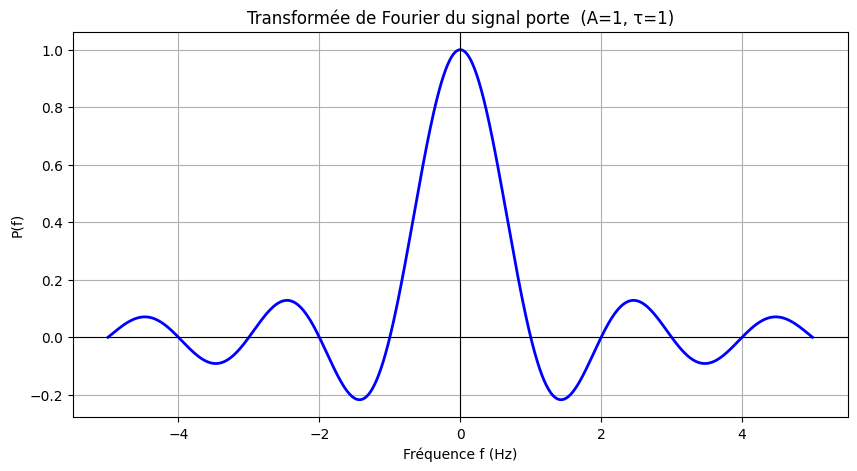

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres du signal porte
A = 1       # amplitude
tau = 1     # durée du signal porte

# Fréquences
f = np.linspace(-5/tau, 5/tau, 1000)

# Transformée de Fourier = A * tau * sinc(f * tau)
P = A * tau * np.sinc(f * tau)

# Tracé
plt.figure(figsize=(10, 5))
plt.plot(f, P, color='blue', linewidth=2)
plt.title(f"Transformée de Fourier du signal porte  (A={A}, τ={tau})")
plt.xlabel("Fréquence f (Hz)")
plt.ylabel("P(f)")
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True)
plt.show()

## D-INTERPREATION PRHYSIQUE 

Le signal porte dans le temps donne une fonction de type **sinc** dans le domaine fréquentiel.

Cela signifie :

- plus le signal est **large dans le temps** ($\tau$ grand), plus son spectre est **resserré** ;
- plus le signal est **court dans le temps**, plus son spectre est **étalé**.

C'est une idée très importante en traitement du signal et en physique des ondes :

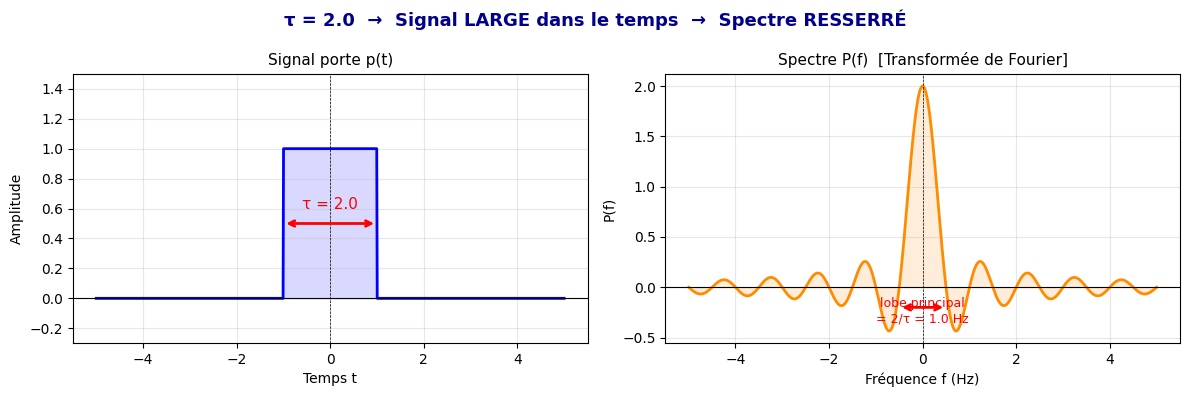

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
A   = 1
tau = 2.0          # ← τ GRAND = signal large dans le temps

# --- Signal porte (domaine temporel) ---
t = np.linspace(-5, 5, 1000)
signal = np.where(np.abs(t) <= tau/2, A, 0)

# --- Transformée de Fourier (domaine fréquentiel) ---
f = np.linspace(-5, 5, 1000)
TF = A * tau * np.sinc(f * tau)

# --- Tracé côte à côte ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"τ = {tau}  →  Signal LARGE dans le temps  →  Spectre RESSERRÉ",
             fontsize=13, fontweight='bold', color='darkblue')

# Graphe gauche : signal porte
ax1.plot(t, signal, color='blue', linewidth=2)
ax1.fill_between(t, signal, alpha=0.15, color='blue')
ax1.set_title("Signal porte p(t)", fontsize=11)
ax1.set_xlabel("Temps t")
ax1.set_ylabel("Amplitude")
ax1.set_ylim(-0.3, 1.5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax1.annotate('', xy=(tau/2, 0.5), xytext=(-tau/2, 0.5),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0, 0.6, f'τ = {tau}', ha='center', color='red', fontsize=11)
ax1.grid(True, alpha=0.3)

# Graphe droit : transformée de Fourier
ax2.plot(f, TF, color='darkorange', linewidth=2)
ax2.fill_between(f, TF, alpha=0.15, color='darkorange')
ax2.set_title("Spectre P(f)  [Transformée de Fourier]", fontsize=11)
ax2.set_xlabel("Fréquence f (Hz)")
ax2.set_ylabel("P(f)")
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax2.annotate('', xy=(1/tau, -0.2), xytext=(-1/tau, -0.2),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(0, -0.35, f'lobe principal\n= 2/τ = {2/tau:.1f} Hz',
         ha='center', color='red', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

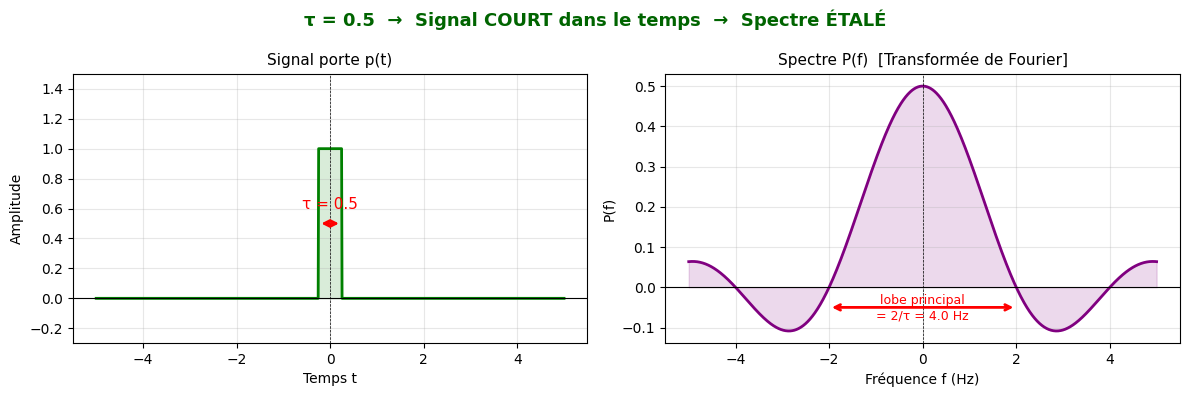

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Paramètres
A   = 1
tau = 0.5          # ← τ PETIT = signal court dans le temps

# --- Signal porte (domaine temporel) ---
t = np.linspace(-5, 5, 1000)
signal = np.where(np.abs(t) <= tau/2, A, 0)

# --- Transformée de Fourier (domaine fréquentiel) ---
f = np.linspace(-5, 5, 1000)
TF = A * tau * np.sinc(f * tau)

# --- Tracé côte à côte ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"τ = {tau}  →  Signal COURT dans le temps  →  Spectre ÉTALÉ",
             fontsize=13, fontweight='bold', color='darkgreen')

# Graphe gauche : signal porte
ax1.plot(t, signal, color='green', linewidth=2)
ax1.fill_between(t, signal, alpha=0.15, color='green')
ax1.set_title("Signal porte p(t)", fontsize=11)
ax1.set_xlabel("Temps t")
ax1.set_ylabel("Amplitude")
ax1.set_ylim(-0.3, 1.5)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax1.annotate('', xy=(tau/2, 0.5), xytext=(-tau/2, 0.5),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax1.text(0, 0.6, f'τ = {tau}', ha='center', color='red', fontsize=11)
ax1.grid(True, alpha=0.3)

# Graphe droit : transformée de Fourier
ax2.plot(f, TF, color='purple', linewidth=2)
ax2.fill_between(f, TF, alpha=0.15, color='purple')
ax2.set_title("Spectre P(f)  [Transformée de Fourier]", fontsize=11)
ax2.set_xlabel("Fréquence f (Hz)")
ax2.set_ylabel("P(f)")
ax2.axhline(0, color='black', linewidth=0.8)
ax2.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax2.annotate('', xy=(1/tau, -0.05), xytext=(-1/tau, -0.05),
             arrowprops=dict(arrowstyle='<->', color='red', lw=2))
ax2.text(0, -0.08, f'lobe principal\n= 2/τ = {2/tau:.1f} Hz',
         ha='center', color='red', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## E-PERIODISATION DU SIGNAL PORTE 

# Périodisation du signal porte par convolution avec un peigne de Dirac

---

## 1) Rappel des deux signaux

### Le signal porte

$$
p(t)=
\begin{cases}
A & \text{si } |t|\le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

### Le peigne de Dirac

$$
\amalg\!\amalg\!\amalg_T(t) \overset{\text{def}}{=} \sum_{k=-\infty}^{+\infty} \delta_k^T(t) = \sum_{k=-\infty}^{+\infty} \delta(t - kT)
$$

où :

- $T$ est la **période** de répétition,
- $\delta(t - kT)$ est une impulsion de Dirac centrée en $t = kT$,
- $k$ parcourt tous les entiers de $-\infty$ à $+\infty$.

---

## 2) Définition de la convolution

Le produit de convolution de deux signaux $f$ et $g$ est défini par :

$$
(f * g)(t) = \int_{-\infty}^{+\infty} f(\xi)\, g(t - \xi)\, d\xi
$$

On cherche donc :

$$
p_p(t) = p(t) * \amalg\!\amalg\!\amalg_T(t)
$$

c'est-à-dire :

$$
p_p(t) = \int_{-\infty}^{+\infty} p(\xi)\; \amalg\!\amalg\!\amalg_T(t - \xi)\; d\xi
$$

---

## 3) Substitution du peigne de Dirac

On remplace $\amalg\!\amalg\!\amalg_T(t - \xi)$ par sa définition :

$$
\amalg\!\amalg\!\amalg_T(t - \xi) = \sum_{k=-\infty}^{+\infty} \delta(t - \xi - kT)
$$

On injecte dans l'intégrale :

$$
p_p(t) = \int_{-\infty}^{+\infty} p(\xi) \left[ \sum_{k=-\infty}^{+\infty} \delta(t - \xi - kT) \right] d\xi
$$

---

## 4) Interversion somme et intégrale

Comme la somme est infinie mais **convergente au sens des distributions**, on peut intervertir $\sum$ et $\int$ :

$$
p_p(t) = \sum_{k=-\infty}^{+\infty} \int_{-\infty}^{+\infty} p(\xi)\; \delta(t - \xi - kT)\; d\xi
$$

---

## 5) Application de la propriété de filtrage du Dirac

La propriété fondamentale de la distribution de Dirac est :

$$
\int_{-\infty}^{+\infty} f(\xi)\; \delta(\xi - a)\; d\xi = f(a)
$$

Dans notre intégrale, on a $\delta(t - \xi - kT) = \delta\!\left(\xi - (t - kT)\right)$.

On applique la propriété avec $a = t - kT$ et $f = p$ :

$$
\int_{-\infty}^{+\infty} p(\xi)\; \delta\!\left(\xi - (t-kT)\right) d\xi = p(t - kT)
$$

---

## 6) Résultat de la convolution

En substituant dans la somme :

$$
\boxed{
p_p(t) = \sum_{k=-\infty}^{+\infty} p(t - kT)
}
$$

---

## 7) Explication du résultat

Ce résultat est fondamental. Il dit que le signal périodisé $p_p(t)$ est une **somme infinie de copies du signal porte** $p(t)$, chacune **décalée de $kT$** dans le temps :

$$
p_p(t) = \cdots + p(t+2T) + p(t+T) + p(t) + p(t-T) + p(t-2T) + \cdots
$$

Chaque terme $p(t - kT)$ est le signal porte centré en $t = kT$ :

$$
p(t-kT) =
\begin{cases}
A & \text{si } |t - kT| \le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

---

## 8) Condition de non-chevauchement

Pour que les copies ne se **chevauchent pas** (ce qui est la condition pour que la périodisation soit propre), il faut que la largeur du signal porte $\tau$ soit **strictement inférieure** à la période $T$ :

$$
\boxed{\tau < T}
$$

- Si $\tau < T$ → les copies sont **séparées**, pas de chevauchement ✅
- Si $\tau = T$ → les copies se **touchent** exactement ⚠️
- Si $\tau > T$ → les copies se **superposent**, le signal est déformé ❌

---

## 9) Expression explicite de $p_p(t)$

En développant la définition de $p(t - kT)$, le signal périodisé vaut :

$$
p_p(t) = A \sum_{k=-\infty}^{+\infty} \mathbf{1}_{\left[kT - \frac{\tau}{2},\; kT + \frac{\tau}{2}\right]}(t)
$$

où $\mathbf{1}_{[a,b]}(t)$ est la **fonction indicatrice** qui vaut $1$ si $t \in [a,b]$ et $0$ sinon.

Autrement dit, $p_p(t) = A$ sur chaque intervalle $\left[kT - \dfrac{\tau}{2},\; kT + \dfrac{\tau}{2}\right]$ centré en $kT$, et $0$ entre ces intervalles.

---

## 10) Résultat final

$$
\boxed{
p_p(t) = p(t) * \amalg\!\amalg\!\amalg_T(t) = \sum_{k=-\infty}^{+\infty} p(t - kT)
}
$$

avec :

$$
p(t - kT) =
\begin{cases}
A & \text{si } \left|t - kT\right| \le \dfrac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

---

## 11) Interprétation physique

| Opération | Effet |
|---|---|
| $p(t)$ seul | Un seul rectangle de largeur $\tau$ et d'amplitude $A$ |
| $* \;\amalg\!\amalg\!\amalg_T(t)$ | On **recopie** ce rectangle toutes les $T$ secondes |
| $p_p(t)$ | Un signal **périodique** de période $T$, formé de rectangles |

> 💡 **En une phrase :** Convoluer un signal par un peigne de Dirac de période $T$, c'est exactement **rendre ce signal périodique de période $T$**.

---

## 12) Lien avec la transformée de Fourier

Dans le domaine fréquentiel, la convolution devient un **produit** :

$$
P_p(f) = P(f) \cdot \frac{1}{T}\amalg\!\amalg\!\amalg_{1/T}(f)
= \frac{1}{T} \sum_{k=-\infty}^{+\infty} P\!\left(\frac{k}{T}\right) \delta\!\left(f - \frac{k}{T}\right)
$$

Le spectre du signal périodisé est donc un **peigne de Dirac en fréquence**, dont les raies sont espacées de $\dfrac{1}{T}$ et pondérées par les échantillons $P\!\left(\dfrac{k}{T}\right) = A\tau\,\mathrm{sinc}\!\left(\dfrac{k\tau}{T}\right)$.


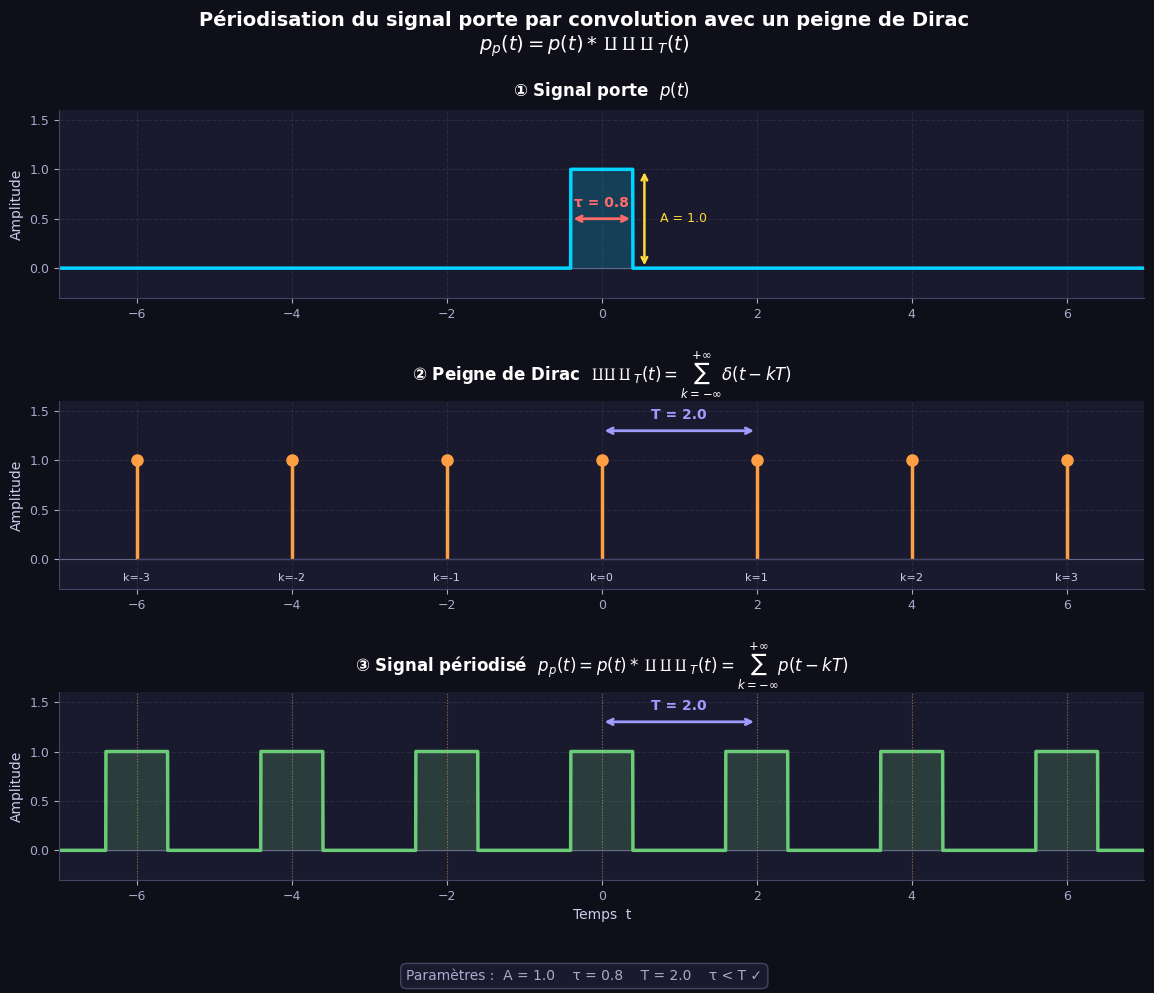

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ============================================================
# PARAMÈTRES
# ============================================================
A   = 1.0    # amplitude du signal porte
tau = 0.8    # largeur du signal porte
T   = 2.0    # période du peigne de Dirac
N   = 3      # nombre de répétitions de chaque côté

t = np.linspace(-N*T - 1, N*T + 1, 5000)

# ============================================================
# 1) SIGNAL PORTE p(t)
# ============================================================
def porte(t, A, tau):
    return np.where(np.abs(t) <= tau/2, A, 0.0)

p = porte(t, A, tau)

# ============================================================
# 2) PEIGNE DE DIRAC — positions et amplitudes
# ============================================================
k_vals    = np.arange(-N, N+1)
t_diracs  = k_vals * T
amp_dirac = np.ones(len(k_vals))

# ============================================================
# 3) SIGNAL PÉRIODISÉ Pp(t) = somme de portes décalées
# ============================================================
Pp = np.zeros_like(t)
for k in k_vals:
    Pp += porte(t - k*T, A, tau)

# ============================================================
# FIGURE — 3 lignes, 1 colonne
# ============================================================
fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#0f0f1a')   # fond sombre

gs = GridSpec(3, 1, figure=fig, hspace=0.55)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

axes = [ax1, ax2, ax3]
for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaacc', labelsize=9)
    ax.spines['bottom'].set_color('#444466')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#444466')
    ax.yaxis.label.set_color('#ccccee')
    ax.xaxis.label.set_color('#ccccee')
    ax.title.set_color('white')
    ax.grid(True, alpha=0.15, color='#8888aa', linestyle='--')
    ax.axhline(0, color='#666688', linewidth=0.8)

# ---- Graphe 1 : Signal porte p(t) -------------------------
ax1.plot(t, p, color='#00d4ff', linewidth=2.5)
ax1.fill_between(t, p, alpha=0.20, color='#00d4ff')
ax1.set_title(r"① Signal porte  $p(t)$", fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel("Amplitude", fontsize=10)
ax1.set_ylim(-0.3, 1.6)
ax1.set_xlim(t[0], t[-1])

# Annotation largeur tau
ax1.annotate('', xy=(tau/2, 0.5), xytext=(-tau/2, 0.5),
             arrowprops=dict(arrowstyle='<->', color='#ff6b6b', lw=2))
ax1.text(0, 0.62, f'τ = {tau}', ha='center', color='#ff6b6b',
         fontsize=10, fontweight='bold')

# Annotation amplitude A
ax1.annotate('', xy=(tau/2 + 0.15, A), xytext=(tau/2 + 0.15, 0),
             arrowprops=dict(arrowstyle='<->', color='#ffd93d', lw=1.8))
ax1.text(tau/2 + 0.35, A/2, f'A = {A}', va='center',
         color='#ffd93d', fontsize=9)

# ---- Graphe 2 : Peigne de Dirac ---------------------------
ml, sl, bl = ax2.stem(t_diracs, amp_dirac,
                       linefmt='#ff9f43', markerfmt='o', basefmt='#444466')
plt.setp(sl, linewidth=2.5, color='#ff9f43')
plt.setp(ml, markersize=8,  color='#ff9f43')
plt.setp(bl, linewidth=1.0)

ax2.set_title(
    r"② Peigne de Dirac  $\amalg\!\amalg\!\amalg_T(t) = \sum_{k=-\infty}^{+\infty} \delta(t - kT)$",
    fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel("Amplitude", fontsize=10)
ax2.set_ylim(-0.3, 1.6)
ax2.set_xlim(t[0], t[-1])

# Annotation période T
ax2.annotate('', xy=(T, 1.3), xytext=(0, 1.3),
             arrowprops=dict(arrowstyle='<->', color='#a29bfe', lw=2))
ax2.text(T/2, 1.42, f'T = {T}', ha='center',
         color='#a29bfe', fontsize=10, fontweight='bold')

# Étiquettes k sous chaque Dirac
for ki, ti in zip(k_vals, t_diracs):
    ax2.text(ti, -0.22, f'k={ki}', ha='center',
             fontsize=8, color='#ccccee')

# ---- Graphe 3 : Signal périodisé Pp(t) --------------------
ax3.plot(t, Pp, color='#6bcb77', linewidth=2.5)
ax3.fill_between(t, Pp, alpha=0.20, color='#6bcb77')
ax3.set_title(
    r"③ Signal périodisé  $p_p(t) = p(t) * \amalg\!\amalg\!\amalg_T(t) = \sum_{k=-\infty}^{+\infty} p(t - kT)$",
    fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel("Temps  t", fontsize=10)
ax3.set_ylabel("Amplitude", fontsize=10)
ax3.set_ylim(-0.3, 1.6)
ax3.set_xlim(t[0], t[-1])

# Annoter la période T sur Pp(t)
ax3.annotate('', xy=(T, 1.3), xytext=(0, 1.3),
             arrowprops=dict(arrowstyle='<->', color='#a29bfe', lw=2))
ax3.text(T/2, 1.42, f'T = {T}', ha='center',
         color='#a29bfe', fontsize=10, fontweight='bold')

# Lignes verticales repères (positions des Diracs)
for ti in t_diracs:
    ax3.axvline(ti, color='#ff9f43', linewidth=0.8,
                linestyle=':', alpha=0.5)

# ============================================================
# TITRE GÉNÉRAL + LÉGENDE
# ============================================================
fig.suptitle(
    "Périodisation du signal porte par convolution avec un peigne de Dirac\n"
    r"$p_p(t) = p(t) * \amalg\!\amalg\!\amalg_T(t)$",
    fontsize=14, fontweight='bold', color='white', y=0.98
)

# Boîte de paramètres
param_text = f"Paramètres :  A = {A}    τ = {tau}    T = {T}    τ < T ✓"
fig.text(0.5, 0.01, param_text, ha='center', fontsize=10,
         color='#aaaacc',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#1a1a2e',
                   edgecolor='#444466'))

plt.savefig('convolution_porte_dirac.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

## F- TRANSFORMER DE FOURRIER D'UN TRAIN D'IMPULSION Pp(t)

# Transformée de Fourier du signal périodisé $P_p(t)$

On considère le signal porte :

$$
p(t)=
\begin{cases}
A & \text{si } |t|\le \frac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

et son signal périodisé :

$$
P_p(t)=p(t)*III_T(t)
$$

où $III_T(t)$ est le peigne de Dirac de période $T$ :

$$
III_T(t)=\sum_{k=-\infty}^{+\infty}\delta(t-kT)
$$

On sait alors que :

$$
P_p(t)=\sum_{k=-\infty}^{+\infty}p(t-kT)
$$

C’est donc une répétition périodique du signal porte, de période $T$.

---

## 1) Convention de transformée de Fourier

On adopte la convention :

$$
X(f)=\int_{-\infty}^{+\infty}x(t)e^{-j2\pi ft}\,dt
$$

et la transformée inverse :

$$
x(t)=\int_{-\infty}^{+\infty}X(f)e^{j2\pi ft}\,df
$$

---

## 2) Transformée de Fourier du signal porte $p(t)$

On a déjà montré que :

$$
P(f)=\mathcal{F}\{p(t)\}=A\tau\,\mathrm{sinc}(f\tau)
$$

avec :

$$
\mathrm{sinc}(x)=\frac{\sin(\pi x)}{\pi x}
$$

Donc :

$$
P(f)=A\tau\,\mathrm{sinc}(f\tau)
$$

---

## 3) Transformée de Fourier du peigne de Dirac

Le peigne de Dirac de période $T$ est :

$$
III_T(t)=\sum_{k=-\infty}^{+\infty}\delta(t-kT)
$$

Sa transformée de Fourier est une propriété classique fondamentale :

$$
\mathcal{F}\{III_T(t)\}=\frac{1}{T}III_{1/T}(f)
$$

c’est-à-dire :

$$
\mathcal{F}\{III_T(t)\}
=
\frac{1}{T}\sum_{n=-\infty}^{+\infty}\delta\left(f-\frac{n}{T}\right)
$$

### Interprétation

- un peigne de Dirac dans le temps donne un peigne de Dirac en fréquence,
- l’espacement $T$ dans le temps devient un espacement $1/T$ en fréquence.

---

## 4) Utilisation du théorème de convolution

On a :

$$
P_p(t)=p(t)*III_T(t)
$$

Or, en transformée de Fourier :

$$
\mathcal{F}\{x(t)*y(t)\}=X(f)\,Y(f)
$$

Donc :

$$
\mathcal{F}\{P_p(t)\}=P(f)\cdot \mathcal{F}\{III_T(t)\}
$$

En remplaçant par les expressions connues :

$$
P_p(f)=P(f)\cdot \frac{1}{T}\sum_{n=-\infty}^{+\infty}\delta\left(f-\frac{n}{T}\right)
$$

Puisque :

$$
P(f)=A\tau\,\mathrm{sinc}(f\tau)
$$

on obtient :

$$
P_p(f)=A\tau\,\mathrm{sinc}(f\tau)\cdot \frac{1}{T}\sum_{n=-\infty}^{+\infty}\delta\left(f-\frac{n}{T}\right)
$$

---

## 5) Propriété de multiplication par un peigne de Dirac

On utilise maintenant la propriété :

$$
g(f)\,\delta(f-f_0)=g(f_0)\,\delta(f-f_0)
$$

Autrement dit, lorsqu’une fonction est multipliée par un Dirac centré en $f_0$, on échantillonne la fonction en $f_0$.

Donc :

$$
A\tau\,\mathrm{sinc}(f\tau)\,\delta\left(f-\frac{n}{T}\right)
=
A\tau\,\mathrm{sinc}\left(\frac{n\tau}{T}\right)\delta\left(f-\frac{n}{T}\right)
$$

En appliquant cela à toute la somme :

$$
P_p(f)=\frac{A\tau}{T}\sum_{n=-\infty}^{+\infty}
\mathrm{sinc}\left(\frac{n\tau}{T}\right)\,
\delta\left(f-\frac{n}{T}\right)
$$

---

## 6) Résultat final

$$
P_p(f)=\frac{A\tau}{T}\sum_{n=-\infty}^{+\infty}
\mathrm{sinc}\left(\frac{n\tau}{T}\right)\,
\delta\left(f-\frac{n}{T}\right)
$$

C’est la transformée de Fourier du signal périodisé.

---

## 7) Signification physique du résultat

Le signal $P_p(t)$ est périodique, donc son spectre n’est **pas continu**.

Au lieu d’obtenir une courbe continue comme pour un signal porte isolé, on obtient un **spectre en raies** :

- une raie à $f=0$,
- une raie à $f=\pm \frac{1}{T}$,
- une raie à $f=\pm \frac{2}{T}$,
- une raie à $f=\pm \frac{3}{T}$,
- etc.

Les amplitudes de ces raies ne sont pas toutes identiques : elles sont pondérées par :

$$
\mathrm{sinc}\left(\frac{n\tau}{T}\right)
$$

Donc l’enveloppe du spectre en raies est donnée par la fonction :

$$
A\tau\,\mathrm{sinc}(f\tau)
$$

### Idée très importante

Le spectre du signal périodisé est un **échantillonnage du spectre du signal porte** aux fréquences :

$$
f=\frac{n}{T}
$$

Donc :

$$
\text{spectre périodique} = \text{raies spectrales sous enveloppe sinc}
$$

---

## 8) Calcul du terme continu $n=0$

Pour $n=0$, on a :

$$
\mathrm{sinc}(0)=1
$$

Donc la raie centrale vaut :

$$
\frac{A\tau}{T}
$$

Ainsi, la composante continue du signal périodique est :

$$
\frac{A\tau}{T}
$$

### Interprétation

Cela correspond à la valeur moyenne du signal sur une période.

En effet, sur une période $T$ :

- le signal vaut $A$ pendant une durée $\tau$,
- il vaut $0$ pendant une durée $T-\tau$.

Donc sa valeur moyenne vaut :

$$
\frac{1}{T}(A\tau)=\frac{A\tau}{T}
$$

ce qui est exactement la même chose.

---

## 9) Lien avec la série de Fourier

Comme $P_p(t)$ est périodique de période $T$, on peut aussi l’écrire sous forme de série de Fourier :

$$
P_p(t)=\sum_{n=-\infty}^{+\infty} c_n e^{j2\pi nt/T}
$$

Pour un signal périodique, la transformée de Fourier s’écrit :

$$
\mathcal{F}\{P_p(t)\}
=
\sum_{n=-\infty}^{+\infty} c_n\,\delta\left(f-\frac{n}{T}\right)
$$

En comparant avec le résultat précédent, on identifie :

$$
c_n=\frac{A\tau}{T}\,\mathrm{sinc}\left(\frac{n\tau}{T}\right)
$$

Donc les coefficients de la série de Fourier du train de portes sont :

$$
c_n=\frac{A\tau}{T}\,\mathrm{sinc}\left(\frac{n\tau}{T}\right)
$$

---

## 10) Cas particulier : écriture sans la fonction sinc

Comme :

$$
\mathrm{sinc}(x)=\frac{\sin(\pi x)}{\pi x}
$$

on peut aussi écrire :

$$
\mathrm{sinc}\left(\frac{n\tau}{T}\right)
=
\frac{\sin\left(\pi n\tau/T\right)}{\pi n\tau/T}
$$

Donc :

$$
P_p(f)=\frac{A\tau}{T}\sum_{n=-\infty}^{+\infty}
\frac{\sin\left(\pi n\tau/T\right)}{\pi n\tau/T}
\,\delta\left(f-\frac{n}{T}\right)
$$

En simplifiant, on peut écrire pour $n\neq 0$ :

$$
c_n=A\frac{\sin(\pi n\tau/T)}{\pi n}
$$

et pour $n=0$ :

$$
c_0=\frac{A\tau}{T}
$$

Donc :

$$
c_n=
\begin{cases}
\frac{A\tau}{T} & \text{si } n=0 \\
A\frac{\sin(\pi n\tau/T)}{\pi n} & \text{si } n\neq 0
\end{cases}
$$

---

## 11) Résumé final à retenir

On part du signal périodisé :

$$
P_p(t)=p(t)*III_T(t)
$$

avec :

$$
p(t)=
\begin{cases}
A & \text{si } |t|\le \frac{\tau}{2} \\
0 & \text{sinon}
\end{cases}
$$

La transformée de Fourier du signal porte vaut :

$$
P(f)=A\tau\,\mathrm{sinc}(f\tau)
$$

La transformée de Fourier du peigne de Dirac vaut :

$$
\mathcal{F}\{III_T(t)\}
=
\frac{1}{T}\sum_{n=-\infty}^{+\infty}\delta\left(f-\frac{n}{T}\right)
$$

Donc :

$$
P_p(f)=\frac{A\tau}{T}\sum_{n=-\infty}^{+\infty}
\mathrm{sinc}\left(\frac{n\tau}{T}\right)\,
\delta\left(f-\frac{n}{T}\right)
$$

Le spectre du signal périodique est donc un **spectre en raies**, situé aux fréquences multiples de $1/T$, avec une enveloppe de type **sinc**.

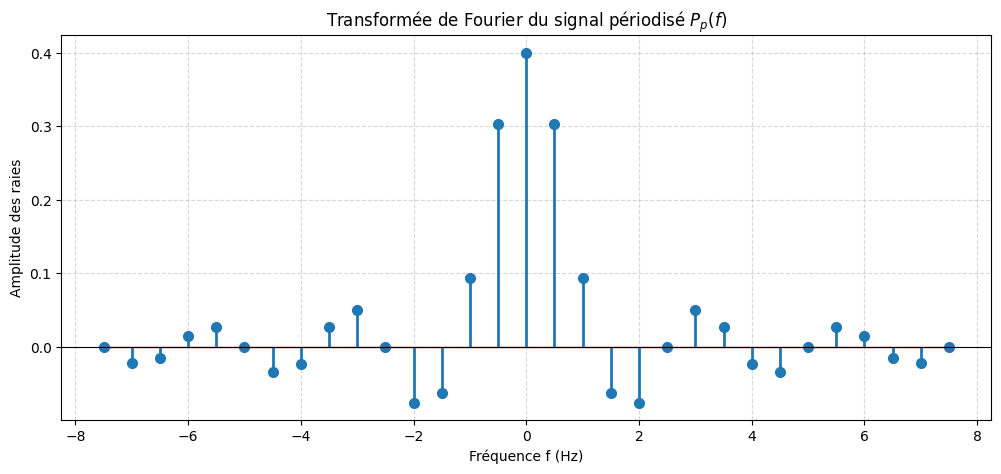

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMÈTRES
# ============================================================
A = 1.0       # amplitude de la porte
tau = 0.8     # largeur de la porte
T = 2.0       # période du signal périodisé
N = 15        # nombre de raies tracées de chaque côté

# ============================================================
# AXE DES INDICES n ET FRÉQUENCES fn = n/T
# ============================================================
n = np.arange(-N, N+1)
f_n = n / T

# ============================================================
# COEFFICIENTS DE FOURIER / AMPLITUDES DES RAIES
# sinc de numpy : np.sinc(x) = sin(pi x)/(pi x)
# ============================================================
C_n = (A * tau / T) * np.sinc(n * tau / T)

# ============================================================
# TRACÉ DU SPECTRE EN RAIES
# ============================================================
plt.figure(figsize=(12, 5))

markerline, stemlines, baseline = plt.stem(f_n, C_n)
plt.setp(stemlines, linewidth=2)
plt.setp(markerline, markersize=7)
plt.setp(baseline, linewidth=1)

plt.axhline(0, color='black', linewidth=0.8)
plt.grid(True, linestyle='--', alpha=0.5)

plt.title(r"Transformée de Fourier du signal périodisé $P_p(f)$")
plt.xlabel("Fréquence f (Hz)")
plt.ylabel("Amplitude des raies")

plt.show()

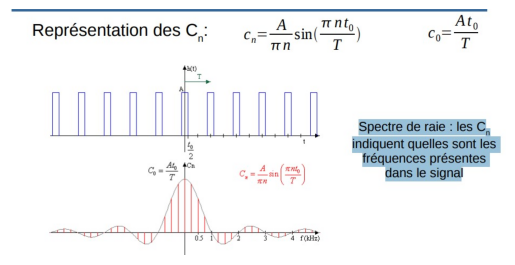

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(r'C:\Users\loica\OneDrive\Desktop\image\image2.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()